# Universitat Oberta de Catalunya  
## Grado en Ingeniería Informática  
### Trabajo Final de Grado (TFG)

---

## Sistema de recomendaciones basado en técnicas de aprendizaje automático para ampliar la exploración de géneros musicales 
**Autor:** Marc Fernández Pereira  
**Bajo supervisión de:** Dra. María Moreno de Castro  
**Área:** Inteligencia Artificial  
**Semestre:** Otoño 2025  




---

## Índice

6. Evaluación de modelos

    - 6.1 Visualización comparativa de métricas

In [ ]:
# Este import centraliza todas las librerías estándar, scikit-learn y funciones personalizadas
from imports import *

c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cargar dataset preprocesado
df = pd.read_csv('spotify_tracks_clean.csv')

# Cargar scaler y PCA
scaler = joblib.load('scaler_object.pkl')
pca = joblib.load('models/pca_95var.pkl')

# Variables utilizadas en el modelado de clustering
selected_vars = ['energy', 'acousticness', 'danceability', 'valence', 'tempo', 'liveness']

# Matriz de características original
X = df[selected_vars].copy()

# Datos estandarizados (mismas variables que en el cuaderno de modelado)
df_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=[f"{col}_norm" for col in selected_vars]
)

# Proyección PCA (mismas componentes que en el cuaderno de modelado)
X_pca = pca.transform(df_scaled)
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Cargar modelos de clustering
kmeans_k4_estand = joblib.load('models/kmeans_k4_estand.pkl')
kmeans_k7_estand = joblib.load('models/kmeans_k7_estand.pkl')
kmeans_k4_pca = joblib.load('models/kmeans_k4_pca.pkl')
kmeans_k7_pca = joblib.load('models/kmeans_k7_pca.pkl')
gmm_n20_pca = joblib.load('models/gmm_n20_pca.pkl')

# Cargar métricas guardadas desde el notebook de clustering
metrics_k7 = joblib.load('metrics/metrics_k7_estand.pkl')
metrics_k4_pca = joblib.load('metrics/metrics_k4_pca.pkl')
metrics_k7_pca = joblib.load('metrics/metrics_k7_pca.pkl')
metrics_k4_medoids = joblib.load('metrics/metrics_k4_medoids.pkl')
metrics_k7_medoids = joblib.load('metrics/metrics_k7_medoids.pkl')


# 6. Evaluación de modelos

Llegados a este punto, se procede a realizar una comparativa general entre todos los modelos 

## 6.1 Visualización comparativa de métricas

A continuación se presentan dos visualizaciones que permiten comparar de forma visual el rendimiento de todos los algoritmos evaluados:


In [4]:

# Comparativa final con las mejores métricas de cada algoritmo estudiado        
# Nota: DBSCAN/OPTICS se ha descartado por ser algoritmos no adecuados para el dataset                                                                          
labels_gmm = gmm_n20_pca.predict(X_pca)
metrics_gmm_20 = compute_cluster_metrics(X_pca, labels_gmm)

# Cálculo de métricas de K-Means sin PCA para comparación
# Usamos las variables estandarizadas (df_scaled) para mantener consistencia con el notebook de clustering
# y KMeans con random_state=42 para reproducibilidad
kmeans_k4_estand = KMeans(n_clusters=4, random_state=42, n_init=10)
k4_labels = kmeans_k4_estand.fit_predict(df_scaled)
metrics_k4_sin_pca = compute_cluster_metrics(df_scaled.values, k4_labels)

# Mejores configuraciones según análisis:
# - K-Means: k=4 y k=7 con PCA (k=4: mejores métricas; k=7: mayor diversidad para recomendación)                                                                
# - K-Means: k=4 y k=7 sin PCA (para comparación con PCA)
# - K-Medoids: k=4 y k=7 con PCA (comparación en igualdad de condiciones)       
# - GMM: n=20 con PCA (seleccionado mediante BIC, mejor Davies-Bouldin)
metrics_comparativa_final = pd.DataFrame(
    [
        metrics_k4_sin_pca,  # K-Means k=4 sin PCA (comparación)
        metrics_k7,          # K-Means k=7 sin PCA (comparación)
        metrics_k4_pca,      # K-Means k=4 con PCA (mejores métricas)
        metrics_k7_pca,      # K-Means k=7 con PCA (mayor diversidad)
        metrics_k4_medoids,  # K-Medoids k=4 con PCA (muestra)
        metrics_k7_medoids,  # K-Medoids k=7 con PCA (muestra)
        metrics_gmm_20       # GMM n=20 con PCA
    ],
    index=['K-Means k=4 (sin PCA)', 'K-Means k=7 (sin PCA)', 'K-Means k=4 (PCA)', 'K-Means k=7 (PCA)', 'K-Medoids k=4 (PCA)', 'K-Medoids k=7 (PCA)', 'GMM n=20 (PCA)']                                            
)

display(metrics_comparativa_final)

,Silhouette,Davies_Bouldin,Calinski_Harabasz
K-Means k=4 (sin PCA),0.24,1.38,24267.37
K-Means k=7 (sin PCA),0.18,1.45,19274.82
K-Means k=4 (PCA),0.25,1.33,26035.87
K-Means k=7 (PCA),0.20,1.38,21036.46
K-Medoids k=4 (PCA),0.19,1.61,5051.27
K-Medoids k=7 (PCA),0.16,1.65,4075.17
GMM n=20 (PCA),0.04,1.75,7788.00


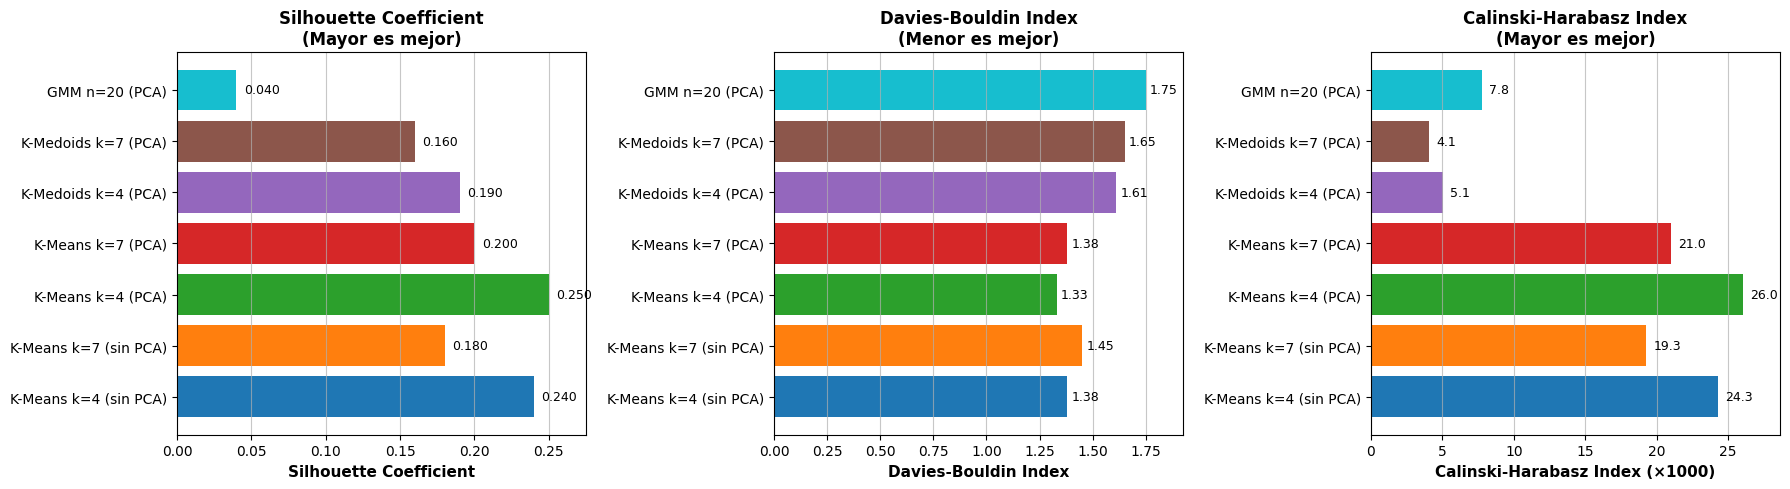

In [5]:
# Visualización comparativa de métricas

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Preparamos
metrics = metrics_comparativa_final.index
silhouette = metrics_comparativa_final['Silhouette']
davies_bouldin = metrics_comparativa_final['Davies_Bouldin']
calinski_harabasz = metrics_comparativa_final['Calinski_Harabasz']

# Normalizar Calinski-Harabasz para mejorar la visibilidad frente al resto de índices
calinski_norm = calinski_harabasz / 1000

# Gráfico Silhouette (mayor es mejor)
# Usar los primeros 5 colores de la paleta definida
colors = palette_colors[:len(metrics)]

axs[0].barh(metrics, silhouette, color=colors)
axs[0].set_xlabel('Silhouette Coefficient', fontsize=11, fontweight='bold')
axs[0].set_title('Silhouette Coefficient\n(Mayor es mejor)', fontsize=12, fontweight='bold')
axs[0].grid(axis='x', alpha=0.7)
axs[0].set_xlim(0, max(silhouette) * 1.1)
# Añadir valores en las barras
for i, v in enumerate(silhouette):
    axs[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico Davies-Bouldin (menor es mejor)
axs[1].barh(metrics, davies_bouldin, color=colors)
axs[1].set_xlabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
axs[1].set_title('Davies-Bouldin Index\n(Menor es mejor)', fontsize=12, fontweight='bold')
axs[1].grid(axis='x', alpha=0.7)
axs[1].set_xlim(0, max(davies_bouldin) * 1.1)
# Añadir valores en las barras
for i, v in enumerate(davies_bouldin):
    axs[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

# Gráfico Calinski-Harabasz (mayor es mejor)
axs[2].barh(metrics, calinski_norm, color=colors)
axs[2].set_xlabel('Calinski-Harabasz Index (×1000)', fontsize=11, fontweight='bold')
axs[2].set_title('Calinski-Harabasz Index\n(Mayor es mejor)', fontsize=12, fontweight='bold')
axs[2].grid(axis='x', alpha=0.7)
axs[2].set_xlim(0, max(calinski_norm) * 1.1)
# Añadir valores en las barras
for i, v in enumerate(calinski_norm):
    axs[2].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


Las métricas de validación interna muestran que K-Means obtiene mejores resultados que K-Medoids y GMM. Entre las configuraciones de K-Means, k=4 presenta las mejores métricas (Silhouette = 0.25, Davies-Bouldin = 1.33, Calinski-Harabasz = 26035.87), mientras que k=7 ofrece más diversidad para el sistema de recomendación (Silhouette = 0.20, Davies-Bouldin = 1.38, Calinski-Harabasz = 21036.46). K-Medoids consigue resultados similares a K-Means pero con métricas ligeramente inferiores. Por su parte, GMM con n=20 componentes (seleccionado mediante BIC) presenta valores más bajos en las tres métricas (Silhouette = 0.04, Davies-Bouldin = 1.75, Calinski-Harabasz = 7788.00).

Estos resultados deben interpretarse considerando el objetivo del proyecto: explorar géneros musicales mediante la identificación de canciones con características similares. Las métricas indican que K-Means genera agrupaciones más nítidas en términos de separación y cohesión interna. Sin embargo, GMM aporta información probabilística que permite cuantificar la incertidumbre de asignación de las canciones a los clústeres e identificar canciones con características intermedias situadas en las fronteras entre géneros, lo cual resulta muy útil para descubrir música menos conocida y facilitar la exploración entre estilos distintos.

En resumen, K-Means con k=4 o k=7 constituye la mejor opción para generar agrupaciones con buena separación y cohesión, mientras que GMM resulta especialmente valioso cuando se busca identificar canciones intermedias y cuantificar la certeza de las asignaciones para potenciar la exploración musical.